# Sparsity: How MAP and Posterior Evolve with More Answers

This notebook shows how a user's **MAP estimate** and **posterior distribution** evolve as we
incrementally reveal answers — from 0 (prior only) to all items answered.

We highlight the moment when the user's **final position** (with all answers) first falls
within the **1-sigma region** of the current posterior, i.e. the point at which the model
has gathered enough evidence to be confident about where the user will end up.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from ixplore import IXPLORE
from ixplore.visualization import colormap, neutral_color, blue_hex, orange_hex

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [2]:
# Load data and pretrained model
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
reactions = reactions / reactions.max().max()

pretrained_embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
pretrained_models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)
users_df = pd.read_csv('../data/synthetic_users.csv', index_col=0)

xplore = IXPLORE(reactions, pretrained_embedding=pretrained_embedding, pretrained_models=pretrained_models)

ixplore - INFO - 2026-03-14 12:33:08 - Number of users for model: 250
ixplore - INFO - 2026-03-14 12:33:08 - Number of items: 70
ixplore - INFO - 2026-03-14 12:33:08 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 12:33:08 - Grid created with resolution 200x200, total 40000 points
ixplore - INFO - 2026-03-14 12:33:08 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 12:33:08 - Random state set to 0
ixplore - INFO - 2026-03-14 12:33:08 - Used pretrained embedding.
ixplore - INFO - 2026-03-14 12:33:08 - Used pretrained model parameters.


### Helper: compute posterior mean and std from grid posterior

In [3]:
def posterior_stats(xplore, posterior):
    """Compute weighted mean, std, and covariance from a grid posterior."""
    X = xplore.X  # (grid_size, 2)
    p = posterior.reshape(-1, 1)  # (grid_size, 1)
    mean = (p * X).sum(axis=0)  # (2,)
    diff = X - mean  # (grid_size, 2)
    cov = (p * diff).T @ diff  # (2, 2) weighted covariance
    std = np.sqrt(np.diag(cov))  # (2,)
    return mean, std, cov


def point_in_1sigma(point, mean, cov):
    """Check if a point falls within the 1-sigma ellipse of a 2D Gaussian."""
    diff = point - mean
    cov_inv = np.linalg.inv(cov)
    mahal_sq = diff @ cov_inv @ diff
    return mahal_sq <= 1.0  # chi2 with 2 dof: 1-sigma corresponds to mahal^2 <= 1

### Track MAP and posterior evolution for one example user

We pick one user, reveal their answers one at a time, and record:
- The MAP estimate at each step
- The posterior mean and covariance
- Whether the final position (all answers) falls within the current 1-sigma ellipse

In [4]:
# Pick an example user
example_user = '42'
user_answers = pd.Series(
    reactions.loc[int(example_user)].values,
    index=xplore.items,
    name=example_user
)
items = user_answers.index.tolist()
n_items = len(items)

# Final position with all answers
final_pos = xplore.embed_new_user(user_answers)
print(f"User {example_user}: final MAP position = ({final_pos[0]:.3f}, {final_pos[1]:.3f})")
print(f"Number of items: {n_items}")

# Track evolution: from 0 answers (prior) to all answers
map_trajectory = []
mean_trajectory = []
std_trajectory = []
cov_trajectory = []
in_1sigma = []

for k in range(n_items + 1):
    if k == 0:
        # Prior only — no answers
        posterior = xplore.prior_X.copy()
    else:
        partial = user_answers.iloc[:k]
        posterior = xplore.posterior_X(partial)
    
    map_pos = xplore.get_point_estimates(posterior)[0]
    mean, std, cov = posterior_stats(xplore, posterior)
    inside = point_in_1sigma(final_pos, mean, cov)
    
    map_trajectory.append(map_pos)
    mean_trajectory.append(mean)
    std_trajectory.append(std)
    cov_trajectory.append(cov)
    in_1sigma.append(inside)

map_trajectory = np.array(map_trajectory)
mean_trajectory = np.array(mean_trajectory)
std_trajectory = np.array(std_trajectory)

# Find first time the final position enters the 1-sigma region
first_in_sigma = next((k for k, v in enumerate(in_1sigma) if v), None)
print(f"Final position first within 1-sigma after {first_in_sigma} answers")

### MAP trajectory over number of answers

MAP estimate trajectory in 2D space as answers are added. Color goes from light (few answers) to dark (all answers). The red star marks the final position. The green ring highlights the step where the final position first enters the 1-sigma region.

In [ ]:
def make_ellipse(mean, cov, **kwargs):
    """Create a 1-sigma ellipse patch from mean and covariance."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * np.sqrt(eigvals)  # 1-sigma
    return Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)


snapshot_steps = [0, 5, 15, 30, n_items]
snapshot_steps = [s for s in snapshot_steps if s <= n_items]

fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(3.2 * len(snapshot_steps), 3.2))

meshgrid_size = xplore.sampling_resolution
xx = xplore.X[:, 0].reshape(meshgrid_size, meshgrid_size)
yy = xplore.X[:, 1].reshape(meshgrid_size, meshgrid_size)

for ax, k in zip(axes, snapshot_steps):
    # Compute posterior
    if k == 0:
        posterior = xplore.prior_X.copy()
    else:
        partial = user_answers.iloc[:k]
        posterior = xplore.posterior_X(partial)
    
    zz = posterior.reshape(meshgrid_size, meshgrid_size)
    ax.contourf(xx, yy, zz, alpha=0.8, cmap=colormap, zorder=1)
    
    # MAP trajectory up to step k
    traj_k = map_trajectory[:k+1]
    colors_k = plt.cm.viridis(np.arange(k+1) / n_items)
    for i in range(len(traj_k) - 1):
        ax.plot(traj_k[i:i+2, 0], traj_k[i:i+2, 1],
                color=colors_k[i], lw=0.8, alpha=0.6, zorder=2)
    ax.scatter(traj_k[:, 0], traj_k[:, 1],
               c=np.arange(k+1), cmap='viridis', vmin=0, vmax=n_items,
               s=8, edgecolors='k', lw=0.2, zorder=3)
    
    # MAP point (current)
    map_pos = xplore.get_point_estimates(posterior)[0]
    ax.scatter(*map_pos, marker='x', color='black', s=30, lw=1.5, zorder=5)
    
    # Final position
    ax.scatter(*final_pos, marker='*', color='red', s=80, edgecolors='k', lw=0.4, zorder=5)
    
    # 1-sigma ellipse
    mean, std, cov = posterior_stats(xplore, posterior)
    inside = point_in_1sigma(final_pos, mean, cov)
    ell_color = '#2ca02c' if inside else 'white'
    ell = make_ellipse(mean, cov, fill=False, edgecolor=ell_color, lw=1.5, ls='--', zorder=4)
    ax.add_patch(ell)
    
    ax.set_xlim(xplore.limits[0] - 0.1, xplore.limits[1] + 0.1)
    ax.set_ylim(xplore.limits[2] - 0.1, xplore.limits[3] + 0.1)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    label = 'prior' if k == 0 else f'{k} answers'
    check = ' $\\checkmark$' if inside else ''
    ax.set_title(f'{label}{check}')

plt.tight_layout()

### Across all users: how many answers until the final position is within 1-sigma?

For every user in the dataset, we incrementally add answers and record when their final position first falls inside the 1-sigma ellipse of the current posterior.

In [6]:
# For each user, find the first k where final position is within 1-sigma
first_in_sigma_all = []

for user_id in xplore.users:
    ua = pd.Series(reactions.loc[int(user_id)].values, index=xplore.items, name=user_id)
    fp = xplore.embed_new_user(ua)
    
    found = n_items  # default: needs all answers
    for k in range(n_items + 1):
        if k == 0:
            post = xplore.prior_X.copy()
        else:
            post = xplore.posterior_X(ua.iloc[:k])
        mean, std, cov = posterior_stats(xplore, post)
        if point_in_1sigma(fp, mean, cov):
            found = k
            break
    first_in_sigma_all.append(found)

first_in_sigma_all = np.array(first_in_sigma_all)
print(f"Median answers to reach 1-sigma: {np.median(first_in_sigma_all):.0f}")
print(f"Mean: {np.mean(first_in_sigma_all):.1f}, Min: {np.min(first_in_sigma_all)}, Max: {np.max(first_in_sigma_all)}")

Median answers to reach 1-sigma: 4
Mean: 6.3, Min: 0, Max: 23


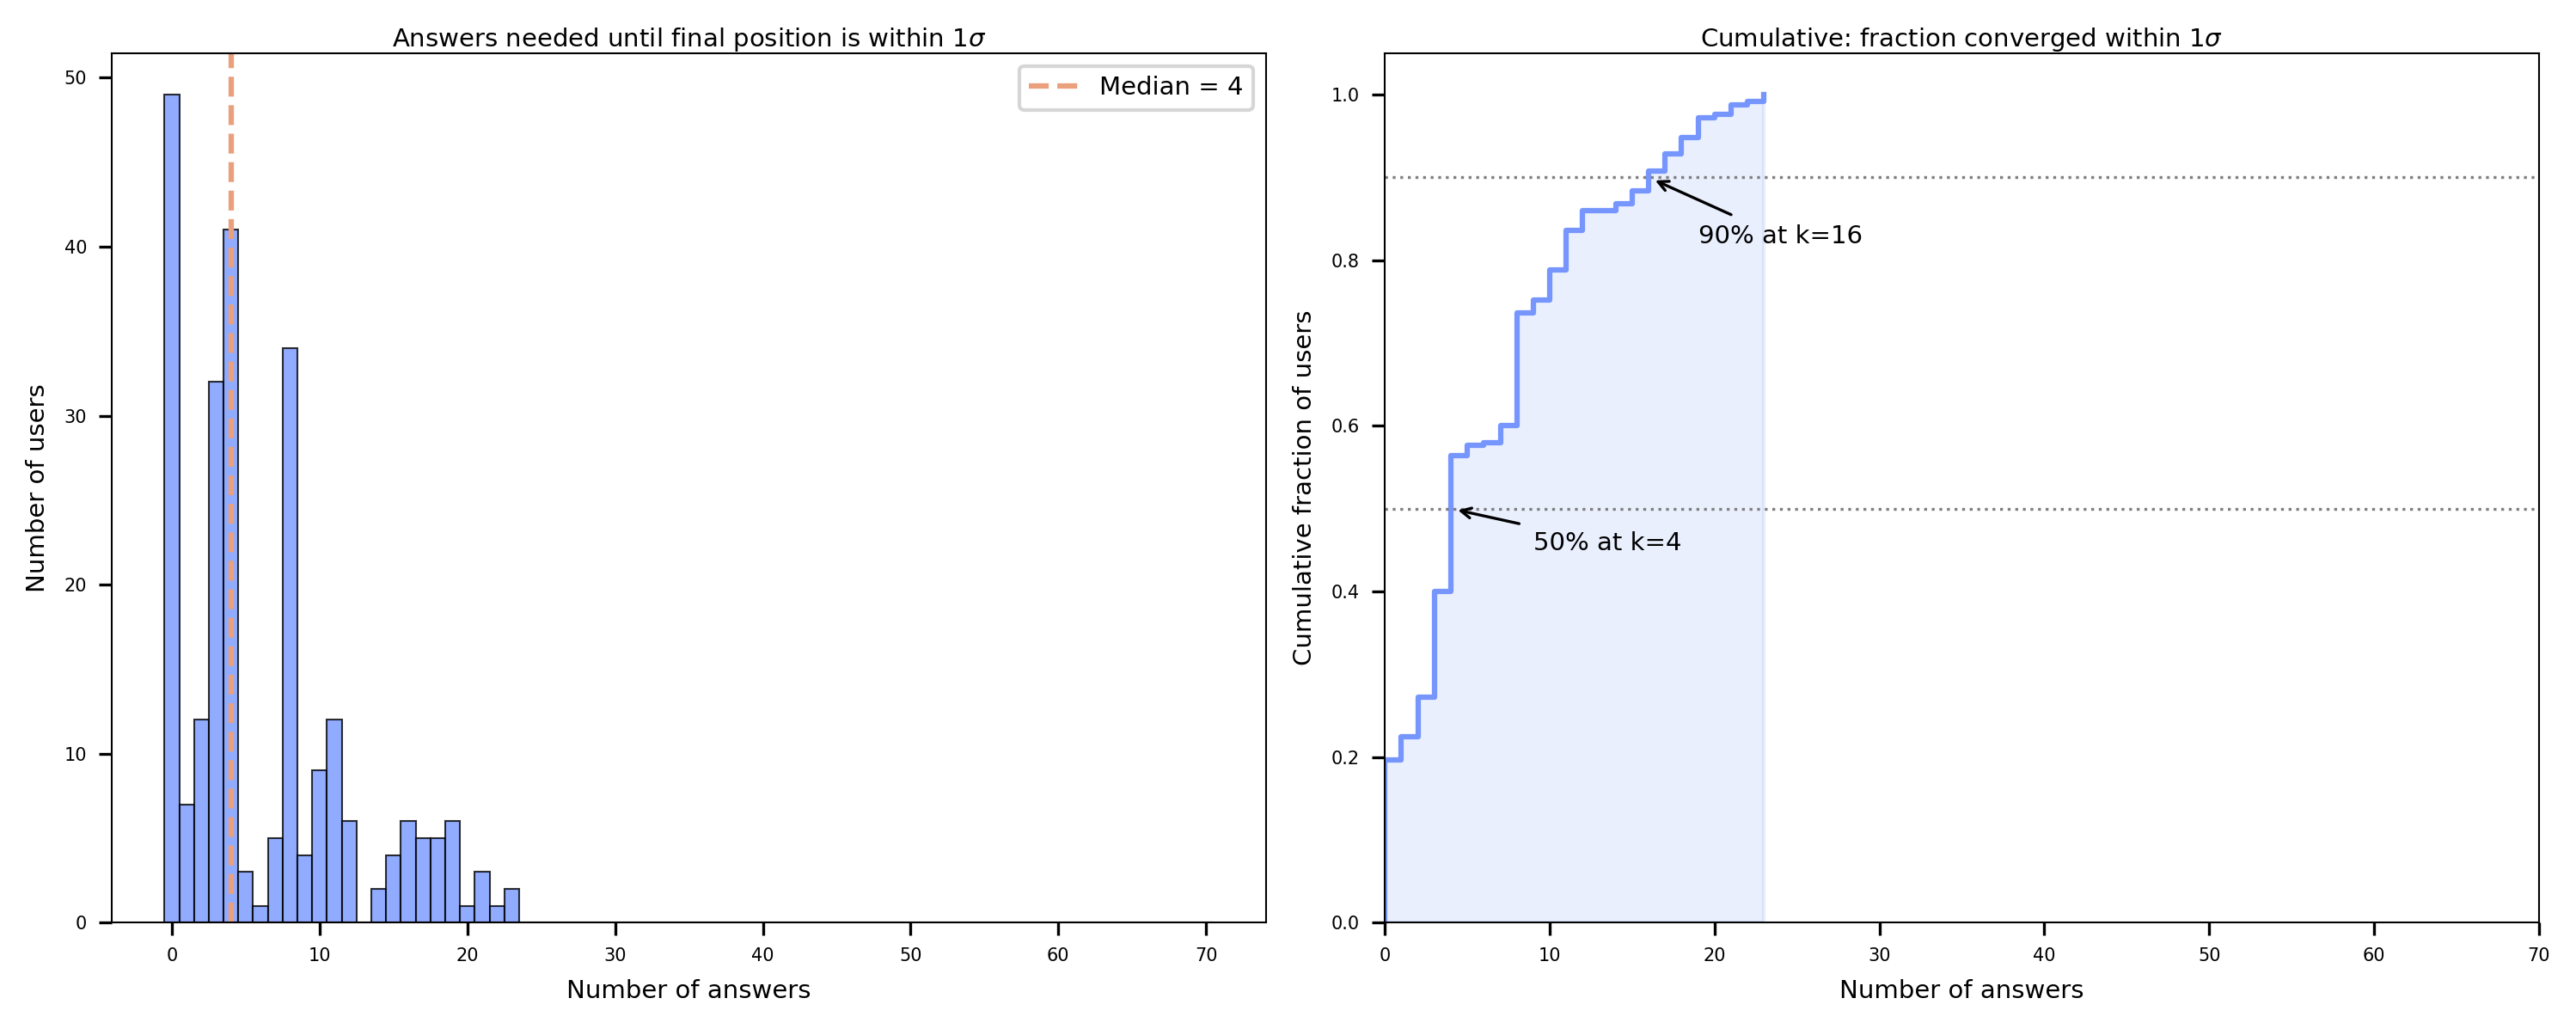

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: histogram of first-in-sigma step ---
bins = np.arange(0, n_items + 2) - 0.5
ax1.hist(first_in_sigma_all, bins=bins, color=blue_hex, edgecolor='k', lw=0.5, alpha=0.8)
ax1.axvline(np.median(first_in_sigma_all), color=orange_hex, ls='--', lw=1.5,
            label=f'Median = {np.median(first_in_sigma_all):.0f}')
ax1.set_xlabel('Number of answers')
ax1.set_ylabel('Number of users')
ax1.set_title('Answers needed until final position is within 1$\\sigma$')
ax1.legend(fontsize=7)

# --- Right: cumulative fraction of users ---
sorted_vals = np.sort(first_in_sigma_all)
cumfrac = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
ax2.step(sorted_vals, cumfrac, color=blue_hex, lw=1.5, where='post')
ax2.fill_between(sorted_vals, 0, cumfrac, step='post', alpha=0.15, color=blue_hex)
ax2.axhline(0.5, color='gray', ls=':', lw=0.8)
ax2.axhline(0.9, color='gray', ls=':', lw=0.8)
ax2.set_xlabel('Number of answers')
ax2.set_ylabel('Cumulative fraction of users')
ax2.set_title('Cumulative: fraction converged within 1$\\sigma$')
ax2.set_xlim(0, n_items)
ax2.set_ylim(0, 1.05)

# Annotate 50% and 90% thresholds
k50 = sorted_vals[np.searchsorted(cumfrac, 0.5)]
k90 = sorted_vals[np.searchsorted(cumfrac, 0.9, side='left')]
ax2.annotate(f'50% at k={k50}', xy=(k50, 0.5), xytext=(k50 + 5, 0.45),
             fontsize=7, arrowprops=dict(arrowstyle='->', lw=0.8))
ax2.annotate(f'90% at k={k90}', xy=(k90, 0.9), xytext=(k90 + 3, 0.82),
             fontsize=7, arrowprops=dict(arrowstyle='->', lw=0.8))

plt.tight_layout()

### MAP distance to final position over number of answers

How the Euclidean distance between the current MAP estimate and the final position (all answers) decreases as more answers are revealed — shown for all users, with the example user highlighted.

In [ ]:
# Compute MAP distance to final for a sample of users
sample_users = xplore.users[:30]  # first 30 users for readability
all_distances = {}

for user_id in sample_users:
    ua = pd.Series(reactions.loc[int(user_id)].values, index=xplore.items, name=user_id)
    fp = xplore.embed_new_user(ua)
    dists = []
    for k in range(n_items + 1):
        if k == 0:
            post = xplore.prior_X.copy()
        else:
            post = xplore.posterior_X(ua.iloc[:k])
        mp = xplore.get_point_estimates(post)[0]
        dists.append(np.linalg.norm(mp - fp))
    all_distances[user_id] = np.array(dists)

steps = np.arange(n_items + 1)

fig, ax = plt.subplots(figsize=(8, 4))

for user_id in sample_users:
    alpha = 0.15 if user_id != example_user else 1.0
    lw = 0.5 if user_id != example_user else 2.0
    color = 'gray' if user_id != example_user else orange_hex
    label = None if user_id != example_user else f'User {example_user}'
    ax.plot(steps, all_distances[user_id], color=color, alpha=alpha, lw=lw, label=label)

# Median across sample
median_dist = np.median([all_distances[u] for u in sample_users], axis=0)
ax.plot(steps, median_dist, color=blue_hex, lw=1.5, ls='--', label='Median (30 users)')

ax.set_xlabel('Number of answers')
ax.set_ylabel('Euclidean distance to final MAP')
ax.set_title('Convergence of MAP estimate to final position')
ax.legend(fontsize=7)
ax.set_xlim(0, n_items)

plt.tight_layout()